In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
points=np.array([
    [1,2],
    [1,4],
    [1,0],
    [5,2],
    [5,4],
    [6,2]
])

labels=["A","B","C","D","E","F"]

In [3]:
ks = [1,2,3,4]
sse = []
for k in ks:
    km = KMeans(n_clusters= k, random_state=42, n_init=50)
    km.fit(points)
    sse.append(km.inertia_)
    print(f"k={k} SSE (Inertia) = {km.inertia_:.6f}")

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=1 SSE (Inertia) = 40.166667
k=2 SSE (Inertia) = 11.333333


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k=3 SSE (Inertia) = 5.333333
k=4 SSE (Inertia) = 2.500000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


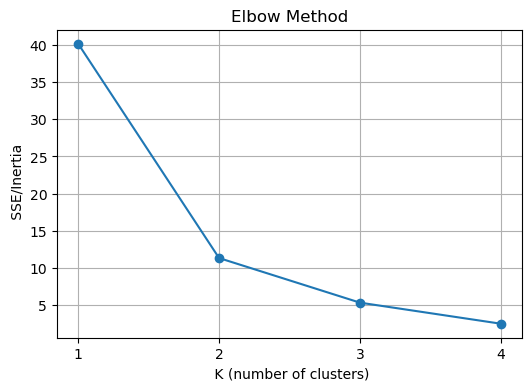

In [5]:
# plot
plt.figure(figsize=(6,4))
plt.plot(ks, sse, '-o')
plt.xticks(ks)
plt.xlabel(' K (number of clusters)')
plt.ylabel(' SSE/Inertia')
plt.title("Elbow Method")
plt.grid(True)
plt.show()

In [9]:
chosen_k = 2
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=50)
kmeans.fit(points)
clusters= kmeans.labels_
centroids = kmeans.cluster_centers_

print("\n Optimal K = ", chosen_k)
for i, label in enumerate(labels):
    print(f"Point {label} {tuple(points[i])} -> cluster {clusters[i]}")
print("Centroids", centroids)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



 Optimal K =  2
Point A (np.int64(1), np.int64(2)) -> cluster 0
Point B (np.int64(1), np.int64(4)) -> cluster 0
Point C (np.int64(1), np.int64(0)) -> cluster 0
Point D (np.int64(5), np.int64(2)) -> cluster 1
Point E (np.int64(5), np.int64(4)) -> cluster 1
Point F (np.int64(6), np.int64(2)) -> cluster 1
Centroids [[1.         2.        ]
 [5.33333333 2.66666667]]


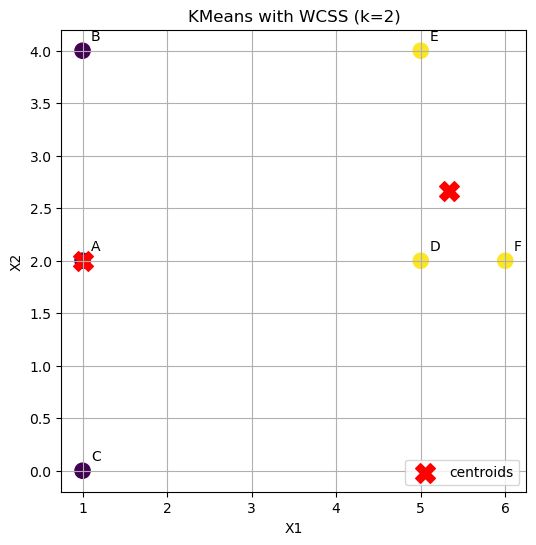

In [16]:
plt.figure(figsize=(6,6))
plt.scatter(points[:,0], points[:,1], c=clusters, s=120, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200, c='red', label='centroids')
for i,txt in enumerate(labels):
    plt.annotate(txt, (points[i,0]+0.1, points[i,1]+0.1))
plt.title(f"KMeans with WCSS (k={chosen_k})")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True)
plt.show()